# **Análisis de series de tiempo 📈**

El análisis de series de tiempo 📈 se centra en datos que se generan de manera secuencial en el tiempo, lo que implica que cada observación está relacionada con las anteriores y posteriores. A diferencia de otros tipos de datos donde se asume independencia entre muestras, en las series temporales aparecen dependencias, tendencias y patrones estacionales que requieren métodos específicos para su estudio. Este análisis es de gran interés porque permite entender la evolución de fenómenos en el tiempo, detectar comportamientos cíclicos y, sobre todo, realizar pronósticos que apoyen la toma de decisiones en áreas como finanzas, energía, salud y medio ambiente. 🌍⏳

Para familiarizarnos con el análisis de series usaremos dos *datasets* : El dataset *AirQualityUCI* 🌫️ contiene mediciones horarias de contaminantes atmosféricos y variables meteorológicas en Italia (2004–2005), lo que lo hace ideal para explorar patrones diarios y estacionales en datos ambientales. En contraste, el clásico dataset *Airline Passengers* 🛫 registra el número mensual de pasajeros de aerolíneas entre 1949 y 1960, mostrando un claro crecimiento de largo plazo y una fuerte estacionalidad anual. Ambos datasets permiten ejemplificar cómo las series de tiempo capturan tanto tendencias como variaciones periódicas, pero en escalas y contextos muy distintos.  



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


## **Air Quality: Resampling y suavizado de series**

In [2]:
air_quality_raw=pd.read_csv('https://raw.githubusercontent.com/asharvi1/UCI-Air-Quality-Data/refs/heads/master/AirQualityUCI.csv',sep=';',decimal=',')

In [3]:
air_quality=(
    air_quality_raw
        .assign(date_time = lambda df: pd.to_datetime(df.Date + " "+ df.Time, format='%d/%m/%Y %H.%M.%S',errors='coerce')
                )[['date_time','CO(GT)']]
        .set_index('date_time')
        .replace(-200, np.nan)
        
)

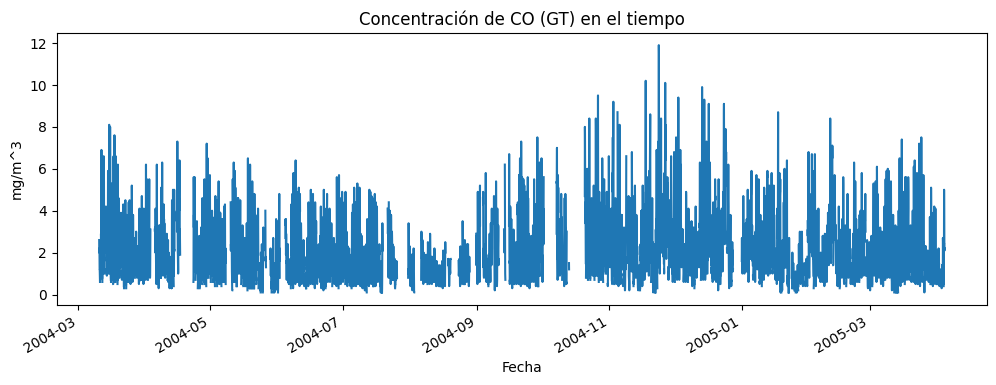

In [4]:
air_quality['CO(GT)'].plot(figsize=(12,4), title="Concentración de CO (GT) en el tiempo")
plt.ylabel("mg/m^3")
plt.xlabel("Fecha")
plt.show()

<Axes: >

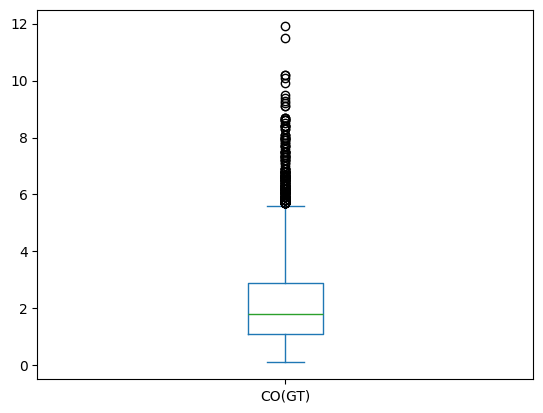

In [5]:
air_quality['CO(GT)'].plot(kind='box')

El método *resample* en pandas permite cambiar la frecuencia temporal de una serie de tiempo 📆. Por ejemplo, al usar `air_quality.resample('W').mean()`, los datos horarios del dataset *AirQualityUCI* se agrupan en intervalos semanales y se calcula el promedio de cada uno. Queremos hacer *resample* porque nos ayuda a suavizar el ruido, facilitar la visualización, comparar patrones en distintas escalas (diaria, semanal, mensual) y adaptar los datos a la granularidad adecuada para el análisis o la construcción de modelos. 🔄


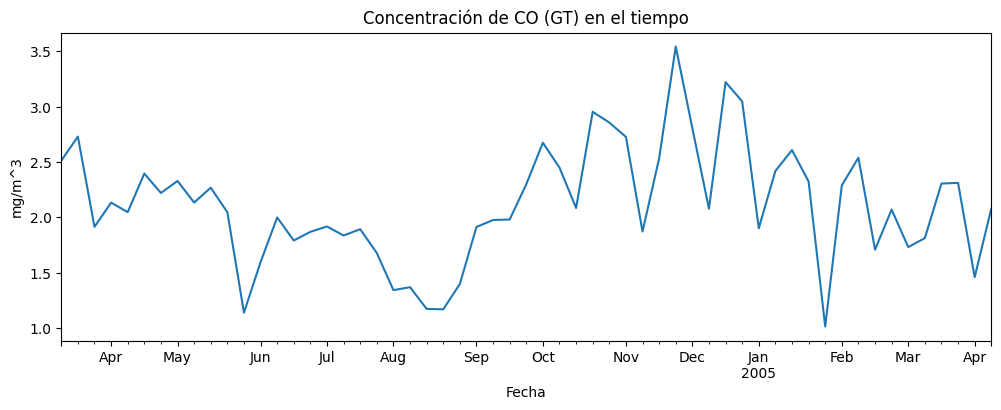

In [6]:
#HDWMQY
air_quality_resample=air_quality.resample('W').mean()
air_quality_resample['CO(GT)'].plot(figsize=(12,4), title="Concentración de CO (GT) en el tiempo")
plt.ylabel("mg/m^3")
plt.xlabel("Fecha")
plt.show()

Suavizar una serie de tiempo 📉 es útil porque nos permite reducir el ruido aleatorio y enfocarnos en las tendencias y patrones principales que de otra manera podrían pasar desapercibidos. Una técnica sencilla para lograrlo es el *promedio móvil*, que consiste en reemplazar cada valor por el promedio de los últimos *k* puntos. De esta forma, los picos aislados se atenúan y se obtiene una curva más clara y estable. Por ejemplo, con `serie.rolling(window=24).mean()` podemos suavizar datos horarios usando una ventana de 24 horas, resaltando así el comportamiento diario sin que las variaciones puntuales dominen la gráfica. ✨


In [7]:
air_quality_resample=(
    air_quality_resample
        .assign(
            rollig_mean_5 = lambda df: df['CO(GT)'].rolling(5).mean(),
            rollig_mean_10 = lambda df: df['CO(GT)'].rolling(10).mean()
        )
)

air_quality_resample

,CO(GT),rollig_mean_5,rollig_mean_10
date_time,,,
2004-03-14,2.513402,NaN,NaN
2004-03-21,2.731056,NaN,NaN
2004-03-28,1.915337,NaN,NaN
2004-04-04,2.134375,NaN,NaN
2004-04-11,2.048077,2.268449,NaN
2004-04-18,2.397059,2.245181,NaN
2004-04-25,2.221538,2.143277,NaN
2004-05-02,2.329814,2.226173,NaN
2004-05-09,2.135043,2.226306,NaN


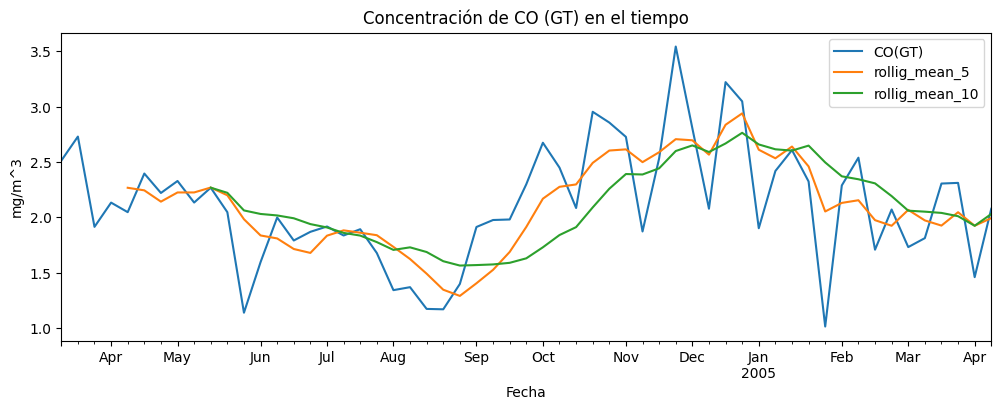

In [8]:
air_quality_resample.plot(figsize=(12,4), title="Concentración de CO (GT) en el tiempo")
plt.ylabel("mg/m^3")
plt.xlabel("Fecha")
plt.show()

## **Airline Passengers: Componentes de la series (tendencia, estacionalidad)**

In [9]:
airline_passengers_raw=pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/refs/heads/master/airline-passengers.csv')

In [10]:
airline_passengers=(
    airline_passengers_raw
        .assign(
            date = lambda df: pd.to_datetime(df.Month,format='%Y-%m')
        )
         .set_index('date')
         .drop(columns='Month')

)
airline_passengers

,Passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


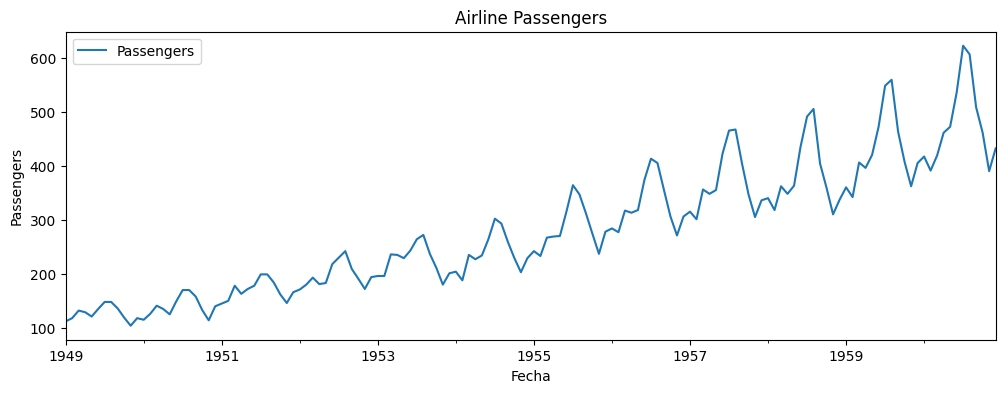

In [11]:
airline_passengers.plot(figsize=(12,4), title="Airline Passengers")
plt.ylabel("Passengers")
plt.xlabel("Fecha")
plt.show()

La descomposición estacional en series de tiempo 🔎 es fundamental porque nos permite separar la señal original en distintos componentes, facilitando la interpretación y el modelado. Con `seasonal_decompose(airline_passengers)` podemos identificar:  
* **Tendencia (Trend)**: el comportamiento de largo plazo, como un crecimiento sostenido.  
* **Estacionalidad (Seasonal)**: los patrones que se repiten en intervalos regulares, como aumentos de pasajeros cada verano.  
* **Residuales (Residuals)**: la parte aleatoria o ruido que no es explicada por la tendencia ni la estacionalidad.  
* **Serie original (Observed)**: los datos tal como se registraron.  

Esta separación ayuda a entender la dinámica de la serie y a mejorar la precisión de los pronósticos. 📈


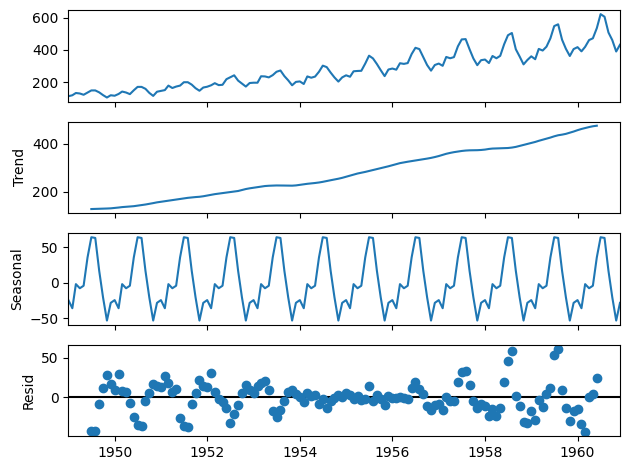

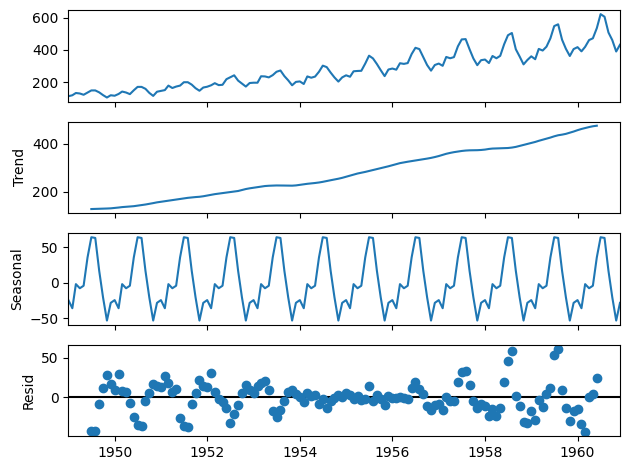

In [12]:
decomposed = seasonal_decompose(airline_passengers)
decomposed.plot()

## **Pronósticos para series de tiempo**

In [13]:
# Dividir datos en entrenamiento y prueba (80%-20%) sin mezclar el orden
train, test = train_test_split(air_quality_resample[['CO(GT)']], shuffle=False, test_size=0.2)

print('Periodo de entrenamiento:', train.index.min(), 'a', train.index.max())
print('Periodo de prueba:', test.index.min(), 'a', test.index.max())

Periodo de entrenamiento: 2004-03-14 00:00:00 a 2005-01-16 00:00:00
Periodo de prueba: 2005-01-23 00:00:00 a 2005-04-10 00:00:00


### **Usando el valor anterior**

Usaremos un modelo de predicción simple  donde se utiliza el valor observado anterior

In [14]:
print('CO (mediana):', test['CO(GT)'].median())

prediction_window_1=(
    test
        .assign(
            preds = lambda df: df['CO(GT)'].shift()
        )
        .dropna()
)
prediction_window_1

CO (mediana): 2.0753463203463203


,CO(GT),preds
date_time,,
2005-01-30,1.014789,2.325185
2005-02-06,2.289697,1.014789
2005-02-13,2.540361,2.289697
2005-02-20,1.709036,2.540361
2005-02-27,2.072121,1.709036
2005-03-06,1.732530,2.072121
2005-03-13,1.813462,1.732530
2005-03-20,2.306667,1.813462
2005-03-27,2.312651,2.306667


In [15]:
print('Error Absoluto Medio (EAM):', mean_absolute_error(prediction_window_1['CO(GT)'], prediction_window_1['preds']))

Error Absoluto Medio (EAM): 0.5836023993170375


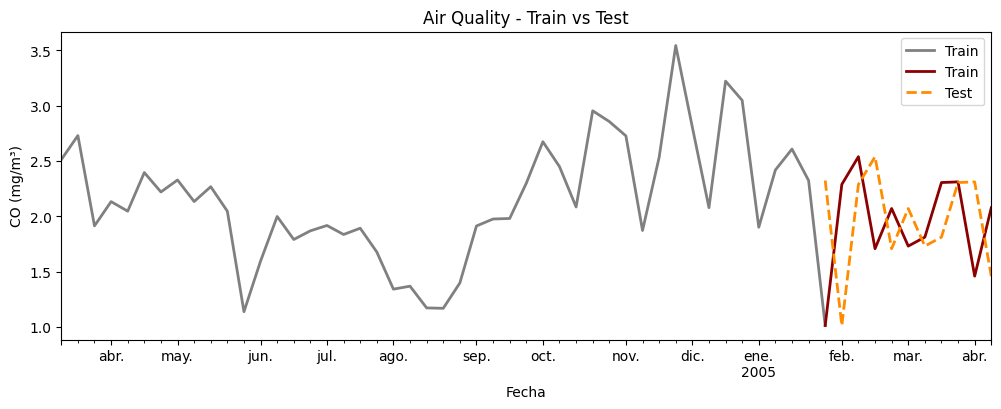

In [25]:
fig, ax = plt.subplots(figsize=(12,4))

air_quality_resample.loc[:"2005-01-30",'CO(GT)'].plot(ax=ax, label='Train', color='gray',linewidth=2)
air_quality_resample.loc["2005-01-30": ,'CO(GT)'].plot(ax=ax, label='Train', color='darkred',linewidth=2)
prediction_window_1.loc["2005-01-09":,'preds'].plot(ax=ax, label='Test', color='darkorange', linestyle='--', linewidth=2)

plt.title("Air Quality - Train vs Test")
plt.xlabel("Fecha")
plt.ylabel("CO (mg/m³)")
plt.legend()
plt.show()

### **Modelo de regresión**

Entrenemos un modelo de regresión lineal para estimar el siguiente valor 

In [17]:
def make_features(data, max_lag, rolling_mean_size):
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['CO(GT)'].shift(lag)
    
    data['rolling_mean'] = data['CO(GT)'].shift().rolling(rolling_mean_size).mean()

    return data.dropna()

In [18]:
train_with_features=make_features(air_quality_resample[['CO(GT)']],4,4)
train, test = train_test_split(train_with_features, shuffle=False, test_size=0.2)
features_train = train.drop(['CO(GT)'],axis=1)
target_train = train['CO(GT)']
features_test = test.drop(['CO(GT)'],axis=1)
target_test = test['CO(GT)']

C:\Users\roman\AppData\Local\Temp\ipykernel_17672\641011821.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['year'] = data.index.year


In [19]:
model = LinearRegression()
model.fit(features_train, target_train)

pred_train = model.predict(features_train)
pred_test = model.predict(features_test)

print('EAM para entrenamiento:', mean_absolute_error(target_train, pred_train))
print('EAM para prueba:', mean_absolute_error(target_test, pred_test))

EAM para entrenamiento: 0.2723738260936326
EAM para prueba: 0.3691958195146759


In [20]:
test=(
    test
        .assign(
            preds = pred_test
        )
)

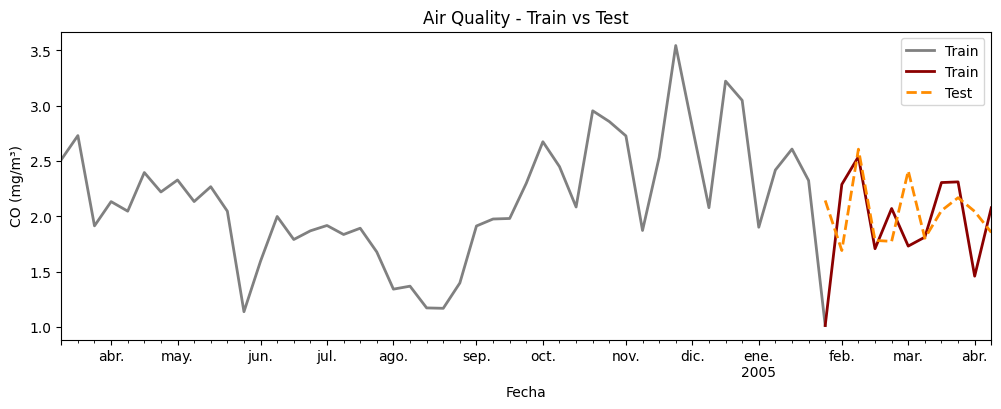

In [24]:

fig, ax = plt.subplots(figsize=(12,4))

air_quality_resample.loc[:"2005-01-30",'CO(GT)'].plot(ax=ax, label='Train', color='gray',linewidth=2)
air_quality_resample.loc["2005-01-30": ,'CO(GT)'].plot(ax=ax, label='Train', color='darkred',linewidth=2)
test.loc["2005-01-09":,'preds'].plot(ax=ax, label='Test', color='darkorange', linestyle='--', linewidth=2)

plt.title("Air Quality - Train vs Test")
plt.xlabel("Fecha")
plt.ylabel("CO (mg/m³)")
plt.legend()
plt.show()


## Para cerrar 💬🤔

----

1. Explica en tus palabras los conceptos de:
    - Resampleo de un serie
    - Suavizado
    - Componentes de una serie
        - Tendencia
        - Estacionalidad
2. ¿De que origen crees que son los datos que pueden ser analizados por series de tiempo?

## 🚀 Para seguir aprendiendo :

---

- 📚 Vuelve a revisar este notebook y trata resolver por tu cuenta el proyecto nuevamente
- 💬 Recuerda que en Discord puedes dejar todos tus comentarios y dudas sobre el contenido del sprint en [Sprint 15](https://discord.com/channels/1081207584104656986/1270074296395497513).
    - 📝 Si tienes preguntas sobre tu proyecto, usa el canal `#project` para recibir ayuda y compartir ideas.
    - 🤝 Aprovecha el espacio de `CoLearning` para aclarar tus dudas junto con otros estudiantes e instructores: [Co-Learning](https://discord.com/channels/1081207584104656986/1197953851391746119).
- 📅 ¿Necesitas ayuda personalizada? Puedes agendar una sesión `1:1` conmigo aquí: [1:1 Roman Castillo](https://scheduler.zoom.us/roman-castillo/1-1-roman-castillo).

- Por último hazme paro y responde la encuesta al final de la sesión, me sirve para poder ayudarte mejor 

¡Sigue practicando y no dudes en pedir apoyo cuando lo necesites! 💪✨